In [1]:
import torch
import sys, os
import math as mt

src_dir = os.path.join(os.path.abspath(''), '..')  # goes up from models/ to src/
configs_dir = os.path.join(os.path.abspath(''), '../..')
sys.path.insert(0, os.path.abspath(src_dir))
sys.path.insert(0, os.path.abspath(configs_dir))

In [2]:
from models.autoencoder import Autoencoder
from models.autoencoder import trainSAE, testSAE
from utils.data_loading import QMatrixData

K = 5
lr = 5e-4
train_epochs = 500
in_channels = 4 
num_channels = 10
kernel_dim = 2
maze_dim = 4
batch_size = 10
gamma_sparse = 1/20*mt.sqrt(maze_dim**2*in_channels/K)
device = None

In [3]:
import numpy as np
import random
seed = 39
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [4]:
BASE_DIR = os.path.abspath(os.path.join(os.path.abspath(''), '..', '..', '..'))

train_dataset = QMatrixData(
    q_file_path=os.path.join(BASE_DIR, "data/teacher/q matrix dictionaries/q_matricestraining_4x4.pkl"),
    label_file_path=os.path.join(BASE_DIR, "data/teacher/label dictionaries/q_matrices_labelstraining_4x4.pkl")
)
test_dataset = QMatrixData(
    q_file_path=os.path.join(BASE_DIR, "data/teacher/q matrix dictionaries/q_matricestest_4x4.pkl"),
    label_file_path=os.path.join(BASE_DIR, "data/teacher/label dictionaries/q_matrices_labelstest_4x4.pkl")
)

autoencoder = Autoencoder(in_channels, maze_dim, num_channels, kernel_dim, K)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=lr)

# training language
total_losses, recon_losses, sparsity_losses, all_messages = trainSAE(autoencoder, train_dataset, gamma_sparse, optimizer, batch_size, train_epochs, device)

# getting messages from trained language
_, _, _, all_messages, message_dict = testSAE(autoencoder, train_dataset, batch_size, gamma_sparse, device)

/Users/melodycui/Downloads/cos435_final_project/.venv/lib/python3.12/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.B

In [ ]:
from configs.experiment_config import ExperimentConfig
from rl.teacher import generate_q_matrices
from evaluation.student_eval import train_student, run_evaluations

config = ExperimentConfig()
q_matrices, label_dict, wall_state_dict, sopt_dict = generate_q_matrices(config, device)
student = train_student(label_dict, wall_state_dict, sopt_dict, message_dict, config, device)

/Users/melodycui/Downloads/cos435_final_project/.venv/lib/python3.12/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.B

Completed calculation of deterministic Q-matrices
training student on task 0
training student on task 1
training student on task 2
training student on task 3
training student on task 4
training student on task 5
training student on task 6
training student on task 7
training student on task 8
training student on task 9
training student on task 10
training student on task 11
training student on task 12
training student on task 13
training student on task 14
training student on task 15
training student on task 16
training student on task 17
training student on task 18
training student on task 19
training student on task 20
training student on task 21
training student on task 22
training student on task 23
training student on task 24
training student on task 25
training student on task 26
training student on task 27
training student on task 28
training student on task 29
training student on task 30
training student on task 31
training student on task 32
training student on task 33
training

TypeError: run_episode() takes 7 positional arguments but 8 were given

In [21]:
import importlib
import evaluation.student_eval as student_eval
importlib.reload(student_eval)
from evaluation.student_eval import train_student, run_evaluations

informed_rates, misinformed_rates = run_evaluations(student, label_dict, wall_state_dict, message_dict, sopt_dict, config, device)

Informed student:    16.65%
Misinformed student: 16.22%


In [18]:
for i in range(5):
    print(label_dict[i])

[0, 0, 1]
[0, 0, 2]
[0, 0, 3]
[0, 0, 4]
[0, 0, 5]


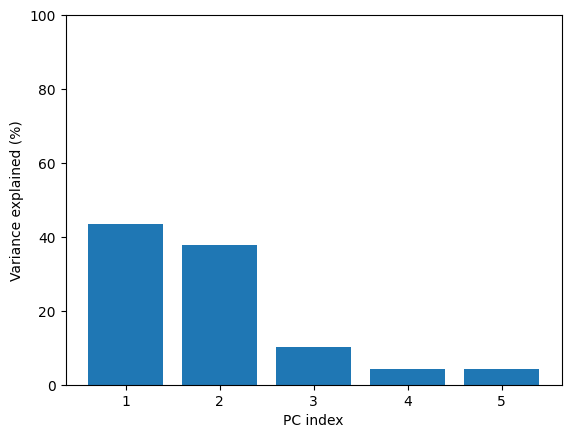

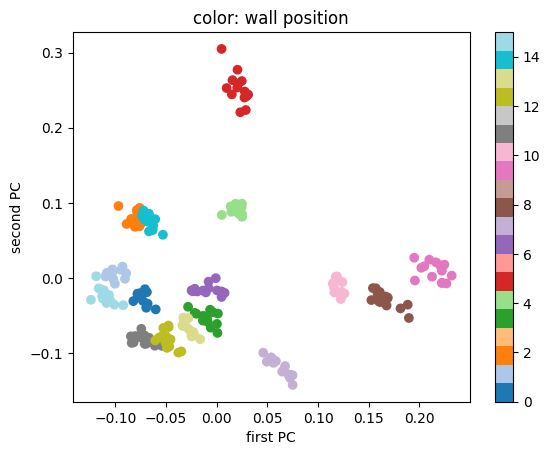

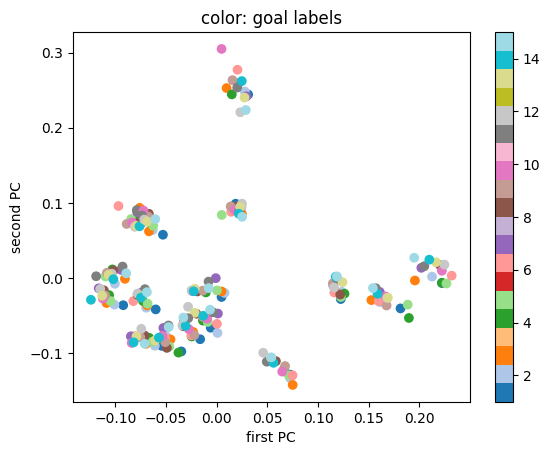

In [ ]:
from sklearn.decomposition import PCA
from utils.plotting import plot_pca_variance, plot_pca_by_label

# Stack all messages into a single tensor
messages = torch.cat(all_messages, dim=0)  # shape: (num_tasks, K)
messages_np = messages.numpy()

wall_labels = [train_dataset.labels[i][0] for i in range(225)]
goal_labels = [train_dataset.labels[i][2] for i in range(225)]

pca = PCA(n_components=5)
pca_result = pca.fit_transform(messages_np)

# get plots
plot_pca_variance(pca)
plot_pca_by_label(pca_result, wall_labels, "color: wall position")
plot_pca_by_label(pca_result, goal_labels, "color: goal labels")